# Product Line Profitability & Margin Performance Analysis
## Nassau Candy Distributor

### Objective
This project aims to analyze product profitability, margin performance, division efficiency, factory contribution, and cost structure diagnostics for Nassau Candy Distributor.

### Business Goals

- Identify high-profit products
- Detect low-margin products
- Evaluate division performance
- Analyze factory profitability
- Perform Pareto (80/20) profit analysis
- Discover cost optimization opportunities
- Build actionable business recommendations

---

In [ ]:
%pip install pandas numpy matplotlib seaborn plotly scipy scikit-learn 

## Improting the reqired Librares

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# Step 1: Load Dataset

The dataset is loaded into a Pandas DataFrame for further inspection and analysis.

In [2]:
df = pd.read_csv("Nassau-Candy-Distributor.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


# Step 2: Dataset Overview

Understanding:

- Number of rows
- Number of columns
- Data types
- Initial records

In [3]:
print("Rows and Columns:")
df.shape

Rows and Columns:


(10194, 18)

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [5]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Country/Region',
 'City',
 'State/Province',
 'Postal Code',
 'Division',
 'Region',
 'Product ID',
 'Product Name',
 'Sales',
 'Units',
 'Gross Profit',
 'Cost']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

# Step 3: Statistical Summary

Review numerical distributions and identify potential anomalies.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Row ID,10194.0,5097.500000,2942.898656,1.00,2549.25,5097.50,7645.75,10194.0
Customer ID,10194.0,134468.961154,20231.483007,100006.00,117212.00,133550.00,152051.00,192314.0
Sales,10194.0,13.908537,11.341020,1.25,7.20,10.80,18.00,260.0
Units,10194.0,3.791838,2.228317,1.00,2.00,3.00,5.00,14.0
Gross Profit,10194.0,9.166451,6.643740,0.25,4.90,7.47,12.25,130.0
Cost,10194.0,4.742087,5.061647,0.60,2.40,3.60,5.70,130.0


# Data Cleaning and Validation

In this section, we verify data quality by:

- Checking duplicate records
- Converting date columns
- Validating Sales, Cost, and Profit values
- Ensuring Gross Profit calculations are consistent

In [8]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records: {duplicates}")

Duplicate Records: 0


In [9]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    dayfirst=True
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    dayfirst=True
)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  str           
 2   Order Date      10194 non-null  datetime64[us]
 3   Ship Date       10194 non-null  datetime64[us]
 4   Ship Mode       10194 non-null  str           
 5   Customer ID     10194 non-null  int64         
 6   Country/Region  10194 non-null  str           
 7   City            10194 non-null  str           
 8   State/Province  10194 non-null  str           
 9   Postal Code     10194 non-null  str           
 10  Division        10194 non-null  str           
 11  Region          10194 non-null  str           
 12  Product ID      10194 non-null  str           
 13  Product Name    10194 non-null  str           
 14  Sales           10194 non-null  float64       
 15  Units        

In [14]:
df.isnull().sum()

Row ID               0
Order ID             0
Order Date           0
Ship Date            0
Ship Mode            0
Customer ID          0
Country/Region       0
City                 0
State/Province       0
Postal Code          0
Division             0
Region               0
Product ID           0
Product Name         0
Sales                0
Units                0
Gross Profit         0
Cost                 0
Calculated Profit    0
dtype: int64

In [11]:
print("Order Date Range:")
print(df['Order Date'].min())
print(df['Order Date'].max())

Order Date Range:
2024-01-02 00:00:00
2025-12-31 00:00:00


In [12]:
df['Calculated Profit'] = (
    df['Sales'] - df['Cost']
)

In [13]:
profit_diff = (
    df['Gross Profit']
    - df['Calculated Profit']
).abs()

profit_diff.describe()

count    1.019400e+04
mean     4.771759e-16
std      8.033726e-16
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      8.881784e-16
max      7.105427e-15
dtype: float64

# Feature Engineering

Creating business metrics required for profitability analysis.

In [15]:
df['Gross Margin %'] = (
    df['Gross Profit'] / df['Sales']
) * 100

In [16]:
df['Profit Per Unit'] = (
    df['Gross Profit'] / df['Units']
)

In [17]:
total_sales = df['Sales'].sum()

df['Revenue Contribution %'] = (
    df['Sales'] / total_sales
) * 100

In [18]:
total_profit = df['Gross Profit'].sum()

df['Profit Contribution %'] = (
    df['Gross Profit'] / total_profit
) * 100

In [19]:
total_revenue = df['Sales'].sum()

total_profit = df['Gross Profit'].sum()

total_cost = df['Cost'].sum()

average_margin = (
    total_profit / total_revenue
) * 100

total_products = df['Product Name'].nunique()

total_orders = df['Order ID'].nunique()

total_divisions = df['Division'].nunique()

total_customers = df['Customer ID'].nunique()

In [20]:
print(f"Total Revenue : ${total_revenue:,.2f}")
print(f"Total Profit  : ${total_profit:,.2f}")
print(f"Total Cost    : ${total_cost:,.2f}")
print(f"Avg Margin    : {average_margin:.2f}%")
print(f"Products      : {total_products}")
print(f"Orders        : {total_orders}")
print(f"Divisions     : {total_divisions}")
print(f"Customers     : {total_customers}")

Total Revenue : $141,783.63
Total Profit  : $93,442.80
Total Cost    : $48,340.83
Avg Margin    : 65.91%
Products      : 15
Orders        : 8549
Divisions     : 3
Customers     : 5044


# Product Profitability Analysis

This section evaluates product-level performance by analyzing:

- Revenue contribution
- Profit contribution
- Gross margin
- Units sold

The goal is to identify the most valuable and least efficient products in the portfolio.

In [21]:
product_summary = (
    df.groupby('Product Name')
      .agg({
          'Sales':'sum',
          'Gross Profit':'sum',
          'Cost':'sum',
          'Units':'sum'
      })
)

product_summary['Margin %'] = (
    product_summary['Gross Profit']
    / product_summary['Sales']
) * 100

product_summary['Profit Per Unit'] = (
    product_summary['Gross Profit']
    / product_summary['Units']
)

product_summary = product_summary.sort_values(
    by='Gross Profit',
    ascending=False
)

product_summary

,Sales,Gross Profit,Cost,Units,Margin %,Profit Per Unit
Product Name,,,,,,
Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,8517.30,7743,69.444444,2.50
Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,9874.80,7596,65.333333,2.45
Wonka Bar - Milk Chocolate,26867.75,17443.37,9424.38,8267,64.923077,2.11
Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755.00,6755,71.346705,2.49
Wonka Bar - Fudge Mallows,24890.40,16593.60,8296.80,6914,66.666667,2.40
Lickable Wallpaper,7860.00,3930.00,3930.00,393,50.000000,10.00
Wonka Gum,597.50,310.70,286.80,478,52.000000,0.65
Everlasting Gobstopper,130.00,104.00,26.00,13,80.000000,8.00
Kazookles,1205.75,92.75,1113.00,371,7.692308,0.25


In [22]:
product_summary.sort_values(
    'Sales',
    ascending=False
).head(10)

,Sales,Gross Profit,Cost,Units,Margin %,Profit Per Unit
Product Name,,,,,,
Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,9874.80,7596,65.333333,2.45
Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,8517.30,7743,69.444444,2.50
Wonka Bar - Milk Chocolate,26867.75,17443.37,9424.38,8267,64.923077,2.11
Wonka Bar - Fudge Mallows,24890.40,16593.60,8296.80,6914,66.666667,2.40
Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755.00,6755,71.346705,2.49
Lickable Wallpaper,7860.00,3930.00,3930.00,393,50.000000,10.00
Kazookles,1205.75,92.75,1113.00,371,7.692308,0.25
Wonka Gum,597.50,310.70,286.80,478,52.000000,0.65
Everlasting Gobstopper,130.00,104.00,26.00,13,80.000000,8.00


In [23]:
product_summary.sort_values(
    'Gross Profit',
    ascending=False
).head(10)

,Sales,Gross Profit,Cost,Units,Margin %,Profit Per Unit
Product Name,,,,,,
Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,8517.30,7743,69.444444,2.50
Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,9874.80,7596,65.333333,2.45
Wonka Bar - Milk Chocolate,26867.75,17443.37,9424.38,8267,64.923077,2.11
Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755.00,6755,71.346705,2.49
Wonka Bar - Fudge Mallows,24890.40,16593.60,8296.80,6914,66.666667,2.40
Lickable Wallpaper,7860.00,3930.00,3930.00,393,50.000000,10.00
Wonka Gum,597.50,310.70,286.80,478,52.000000,0.65
Everlasting Gobstopper,130.00,104.00,26.00,13,80.000000,8.00
Kazookles,1205.75,92.75,1113.00,371,7.692308,0.25


In [24]:
product_summary.sort_values(
    'Margin %',
    ascending=False
).head(10)

,Sales,Gross Profit,Cost,Units,Margin %,Profit Per Unit
Product Name,,,,,,
Everlasting Gobstopper,130.00,104.00,26.00,13,80.000000,8.00
Hair Toffee,76.50,59.50,17.00,17,77.777778,3.50
Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755.00,6755,71.346705,2.49
Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,8517.30,7743,69.444444,2.50
Wonka Bar - Fudge Mallows,24890.40,16593.60,8296.80,6914,66.666667,2.40
Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,9874.80,7596,65.333333,2.45
Wonka Bar - Milk Chocolate,26867.75,17443.37,9424.38,8267,64.923077,2.11
Laffy Taffy,53.73,33.48,20.25,27,62.311558,1.24
Fizzy Lifting Drinks,78.75,47.25,31.50,21,60.000000,2.25


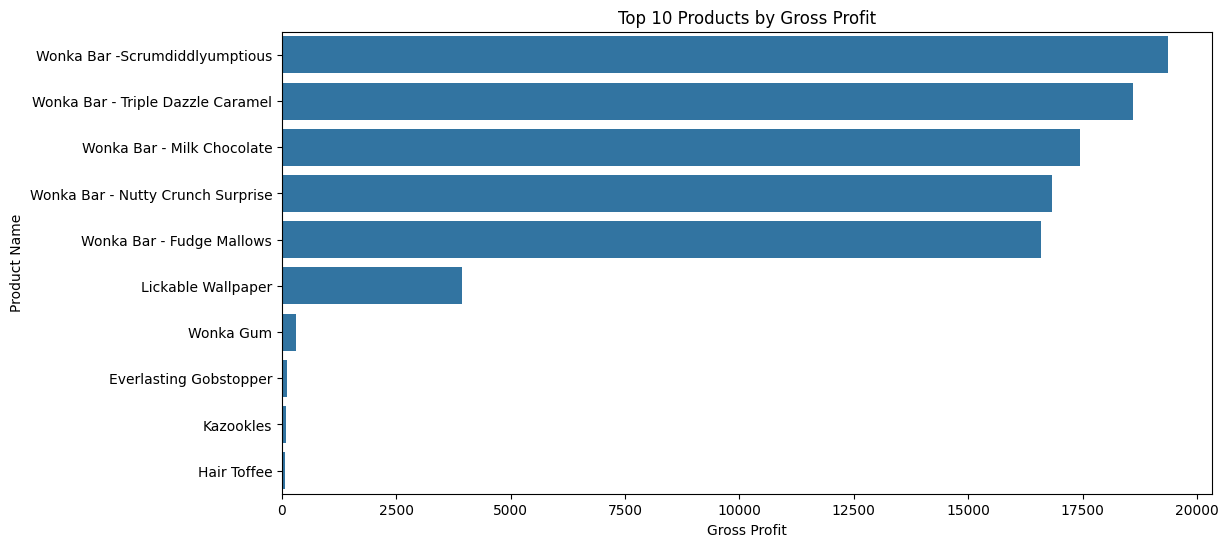

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

top10_profit = (
    product_summary
    .sort_values('Gross Profit', ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10_profit['Gross Profit'],
    y=top10_profit.index
)

plt.title("Top 10 Products by Gross Profit")
plt.xlabel("Gross Profit")
plt.ylabel("Product Name")
plt.show()

In [27]:
product_summary

,Sales,Gross Profit,Cost,Units,Margin %,Profit Per Unit
Product Name,,,,,,
Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,8517.30,7743,69.444444,2.50
Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,9874.80,7596,65.333333,2.45
Wonka Bar - Milk Chocolate,26867.75,17443.37,9424.38,8267,64.923077,2.11
Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755.00,6755,71.346705,2.49
Wonka Bar - Fudge Mallows,24890.40,16593.60,8296.80,6914,66.666667,2.40
Lickable Wallpaper,7860.00,3930.00,3930.00,393,50.000000,10.00
Wonka Gum,597.50,310.70,286.80,478,52.000000,0.65
Everlasting Gobstopper,130.00,104.00,26.00,13,80.000000,8.00
Kazookles,1205.75,92.75,1113.00,371,7.692308,0.25


In [29]:
top_revenue = (
    product_summary
    .sort_values("Sales", ascending=False)
)

top_revenue.head(10)

,Sales,Gross Profit,Cost,Units,Margin %,Profit Per Unit
Product Name,,,,,,
Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,9874.80,7596,65.333333,2.45
Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,8517.30,7743,69.444444,2.50
Wonka Bar - Milk Chocolate,26867.75,17443.37,9424.38,8267,64.923077,2.11
Wonka Bar - Fudge Mallows,24890.40,16593.60,8296.80,6914,66.666667,2.40
Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755.00,6755,71.346705,2.49
Lickable Wallpaper,7860.00,3930.00,3930.00,393,50.000000,10.00
Kazookles,1205.75,92.75,1113.00,371,7.692308,0.25
Wonka Gum,597.50,310.70,286.80,478,52.000000,0.65
Everlasting Gobstopper,130.00,104.00,26.00,13,80.000000,8.00


In [30]:
top_profit = (
    product_summary
    .sort_values("Gross Profit", ascending=False)
)

top_profit.head(10)

,Sales,Gross Profit,Cost,Units,Margin %,Profit Per Unit
Product Name,,,,,,
Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,8517.30,7743,69.444444,2.50
Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,9874.80,7596,65.333333,2.45
Wonka Bar - Milk Chocolate,26867.75,17443.37,9424.38,8267,64.923077,2.11
Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755.00,6755,71.346705,2.49
Wonka Bar - Fudge Mallows,24890.40,16593.60,8296.80,6914,66.666667,2.40
Lickable Wallpaper,7860.00,3930.00,3930.00,393,50.000000,10.00
Wonka Gum,597.50,310.70,286.80,478,52.000000,0.65
Everlasting Gobstopper,130.00,104.00,26.00,13,80.000000,8.00
Kazookles,1205.75,92.75,1113.00,371,7.692308,0.25


In [31]:
low_margin = (
    product_summary
    .sort_values("Margin %", ascending=True)
)

low_margin.head(10)

,Sales,Gross Profit,Cost,Units,Margin %,Profit Per Unit
Product Name,,,,,,
Kazookles,1205.75,92.75,1113.00,371,7.692308,0.25
Fun Dip,12.00,4.80,7.20,8,40.000000,0.60
Nerds,15.00,7.00,8.00,10,46.666667,0.70
SweeTARTS,61.50,28.70,32.80,41,46.666667,0.70
Lickable Wallpaper,7860.00,3930.00,3930.00,393,50.000000,10.00
Wonka Gum,597.50,310.70,286.80,478,52.000000,0.65
Fizzy Lifting Drinks,78.75,47.25,31.50,21,60.000000,2.25
Laffy Taffy,53.73,33.48,20.25,27,62.311558,1.24
Wonka Bar - Milk Chocolate,26867.75,17443.37,9424.38,8267,64.923077,2.11


In [32]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()

In [33]:
monthly_sales = (
    df.groupby('Month')['Sales']
      .sum()
)

In [34]:
monthly_profit = (
    df.groupby('Month')['Gross Profit']
      .sum()
)

In [35]:
region_summary = (
    df.groupby('Region')
      .agg({
          'Sales':'sum',
          'Gross Profit':'sum'
      })
)

In [36]:
state_summary = (
    df.groupby('State/Province')
      .agg({
          'Sales':'sum',
          'Gross Profit':'sum'
      })
      .sort_values(
          'Sales',
          ascending=False
      )
)

In [37]:
factory_map = {
    "Wonka Bar - Nutty Crunch Surprise":"Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows":"Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious":"Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate":"Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel":"Wicked Choccy's",
    "Laffy Taffy":"Sugar Shack",
    "SweeTARTS":"Sugar Shack",
    "Nerds":"Sugar Shack",
    "Fun Dip":"Sugar Shack",
    "Fizzy Lifting Drinks":"Sugar Shack",
    "Everlasting Gobstopper":"Secret Factory",
    "Hair Toffee":"The Other Factory",
    "Lickable Wallpaper":"Secret Factory",
    "Wonka Gum":"Secret Factory",
    "Kazookles":"The Other Factory"
}

In [38]:
df['Factory'] = df['Product Name'].map(factory_map)

In [39]:
factory_summary = (
    df.groupby('Factory')
      .agg({
          'Sales':'sum',
          'Gross Profit':'sum',
          'Cost':'sum'
      })
)

In [40]:
pareto = (
    df.groupby('Product Name')['Gross Profit']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

In [41]:
pareto['Cumulative Profit'] = (
    pareto['Gross Profit'].cumsum()
)

In [42]:
pareto['Cumulative %'] = (
    pareto['Cumulative Profit']
    / pareto['Gross Profit'].sum()
) * 100

In [43]:
product_summary[
    ['Sales',
     'Cost',
     'Gross Profit',
     'Margin %']
].sort_values(
    'Cost',
    ascending=False
)

,Sales,Cost,Gross Profit,Margin %
Product Name,,,,
Wonka Bar - Triple Dazzle Caramel,28485.00,9874.80,18610.20,65.333333
Wonka Bar - Milk Chocolate,26867.75,9424.38,17443.37,64.923077
Wonka Bar -Scrumdiddlyumptious,27874.80,8517.30,19357.50,69.444444
Wonka Bar - Fudge Mallows,24890.40,8296.80,16593.60,66.666667
Wonka Bar - Nutty Crunch Surprise,23574.95,6755.00,16819.95,71.346705
Lickable Wallpaper,7860.00,3930.00,3930.00,50.000000
Kazookles,1205.75,1113.00,92.75,7.692308
Wonka Gum,597.50,286.80,310.70,52.000000
SweeTARTS,61.50,32.80,28.70,46.666667


# Executive Insights and Business Recommendations

This section summarizes the key findings obtained from product profitability analysis, division performance analysis, factory contribution analysis, geographic analysis, and Pareto analysis.

The objective is to provide actionable recommendations that support strategic decision-making for Nassau Candy Distributor.

In [44]:
executive_kpi = pd.DataFrame({
    'Metric': [
        'Total Revenue',
        'Total Profit',
        'Total Cost',
        'Average Margin (%)',
        'Total Products',
        'Total Orders',
        'Total Customers'
    ],
    'Value': [
        total_revenue,
        total_profit,
        total_cost,
        average_margin,
        total_products,
        total_orders,
        total_customers
    ]
})

executive_kpi

,Metric,Value
0,Total Revenue,141783.630000
1,Total Profit,93442.800000
2,Total Cost,48340.830000
3,Average Margin (%),65.905211
4,Total Products,15.000000
5,Total Orders,8549.000000
6,Total Customers,5044.000000


In [45]:
top_revenue_product = (
    product_summary
    .sort_values('Sales', ascending=False)
    .head(1)
)

top_revenue_product

,Sales,Gross Profit,Cost,Units,Margin %,Profit Per Unit
Product Name,,,,,,
Wonka Bar - Triple Dazzle Caramel,28485.0,18610.2,9874.8,7596,65.333333,2.45


In [46]:
top_profit_product = (
    product_summary
    .sort_values('Gross Profit', ascending=False)
    .head(1)
)

top_profit_product

,Sales,Gross Profit,Cost,Units,Margin %,Profit Per Unit
Product Name,,,,,,
Wonka Bar -Scrumdiddlyumptious,27874.8,19357.5,8517.3,7743,69.444444,2.5


In [47]:
highest_margin_product = (
    product_summary
    .sort_values('Margin %', ascending=False)
    .head(1)
)

highest_margin_product

,Sales,Gross Profit,Cost,Units,Margin %,Profit Per Unit
Product Name,,,,,,
Everlasting Gobstopper,130.0,104.0,26.0,13,80.0,8.0


In [48]:
lowest_margin_product = (
    product_summary
    .sort_values('Margin %')
    .head(1)
)

lowest_margin_product

,Sales,Gross Profit,Cost,Units,Margin %,Profit Per Unit
Product Name,,,,,,
Kazookles,1205.75,92.75,1113.0,371,7.692308,0.25


In [49]:
best_division = (
    division_summary
    .sort_values('Gross Profit', ascending=False)
    .head(1)
)

best_division

NameError: name 'division_summary' is not defined